"""
Ridge:
    L2 Penalty
Lasso:
    L1 Penalty
ElasticNet:
    L1 + L2 Penalty
Workflow:

1. Data Understanding
2. EDA
3. Train / Validation / Test Split
4. Preprocessing
5. Baseline Model
6. Validation Metrics
7. Cross Validation
8. Hyperparameter Tuning
9. Validation Re-Evaluation
10. Train vs Validation
11. ElasticNet Specific Analysis
12. Final Model
13. Test Evaluation
14. Interpretation
15. Deployment Readiness
"""

In [2]:
# =====================================================
# IMPORTS
# =====================================================

import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import (train_test_split,GridSearchCV,cross_val_score)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import (ElasticNet,Ridge,Lasso)
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

In [3]:
# =====================================================
# STEP 1 : DATA UNDERSTANDING
# =====================================================

housing = fetch_california_housing()
df = pd.DataFrame(housing.data,columns=housing.feature_names)
df["Target"] = housing.target

print(df.head())
print(df.info())
print(df.describe())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Target  
0    -122.23   4.526  
1    -122.22   3.585  
2    -122.24   3.521  
3    -122.25   3.413  
4    -122.25   3.422  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOc

In [ ]:
# =====================================================
# STEP 2 : EDA
# =====================================================

print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())
print(df.corr())

In [4]:
# =====================================================
# STEP 3 : TRAIN / VALIDATION / TEST
# =====================================================

X = df.drop("Target", axis=1)
y = df["Target"]
X_temp, X_test, y_temp, y_test = train_test_split(X,y,test_size=0.15,random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp,y_temp,test_size=0.1765,random_state=42)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(14447, 8)
(3097, 8)
(3096, 8)


In [5]:
# =====================================================
# STEP 4 : PREPROCESSING
# =====================================================

pipe = Pipeline([("scaler",StandardScaler()),
                 ("model",ElasticNet(alpha=1.0,l1_ratio=0.5,fit_intercept=True,max_iter=10000,tol=0.0001,selection="cyclic",
    random_state=42))])

In [6]:
# =====================================================
# STEP 5 : BASELINE MODEL
# =====================================================

pipe.fit(X_train,y_train)


,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,alpha,1.0
,l1_ratio,0.5
,fit_intercept,True
,precompute,False


In [7]:
# =====================================================
# STEP 6 : VALIDATION METRICS
# =====================================================

val_pred = pipe.predict(X_val)
mae = mean_absolute_error(y_val,val_pred)
mse = mean_squared_error(y_val,val_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_val,val_pred)
n = len(y_val)
p = X_val.shape[1]

adj_r2 = 1 - (
    ((1-r2)*(n-1))
    /(n-p-1)
)

print("\nBASELINE ELASTICNET")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2 :", r2)
print("Adj R2:", adj_r2)


BASELINE ELASTICNET
MAE : 0.8074474678377822
RMSE: 1.0293403270516632
R2 : 0.20801976866882277
Adj R2: 0.20596800641148805


In [8]:
# =====================================================
# STEP 7 : CROSS VALIDATION
# =====================================================

cv_scores = cross_val_score(pipe,X_train,y_train,cv=5,scoring="r2",n_jobs=-1)
print("\nCV Mean:", cv_scores.mean())
print("CV Std :", cv_scores.std())



CV Mean: 0.2050442806134348
CV Std : 0.00525839732226695


In [9]:
# =====================================================
# STEP 8 : HYPERPARAMETER TUNING
# =====================================================

param_grid = {
    "model__alpha":[0.0001,0.001,0.01,0.1,1,10],
    "model__l1_ratio":[0.1,0.3,0.5,0.7,0.9]}

grid = GridSearchCV(pipe,param_grid,cv=5,scoring="r2",n_jobs=-1)
grid.fit(X_train,y_train)
print(grid.best_params_)
print(grid.best_score_)
best_model = grid.best_estimator_

{'model__alpha': 0.001, 'model__l1_ratio': 0.9}
0.602740954786387


In [10]:
# =====================================================
# STEP 9 : VALIDATION RE-EVALUATION
# =====================================================

val_pred = best_model.predict(X_val)
val_r2 = r2_score(y_val,val_pred)
print("\nValidation R2:", val_r2)


Validation R2: 0.6144113999293983


In [11]:
# =====================================================
# STEP 10 : TRAIN VS VALIDATION
# =====================================================

train_pred = best_model.predict(X_train)
train_r2 = r2_score(y_train,train_pred)
print("\nTrain R2:", train_r2)
print("Validation R2:", val_r2)


Train R2: 0.6075480701066271
Validation R2: 0.6144113999293983


[ 0.83299008  0.11800079 -0.28468421  0.31996521 -0.00367133 -0.04529855
 -0.88085641 -0.85065827]
      Feature     Ridge     Lasso  ElasticNet
0      MedInc  0.838016  0.781511    0.832990
1    HouseAge  0.117158  0.122952    0.118001
2    AveRooms -0.298594 -0.144908   -0.284684
3   AveBedrms  0.333815  0.180650    0.319965
4  Population -0.004936 -0.000000   -0.003671
5    AveOccup -0.046184 -0.035619   -0.045299
6    Latitude -0.890486 -0.792482   -0.880856
7   Longitude -0.860932 -0.754984   -0.850658


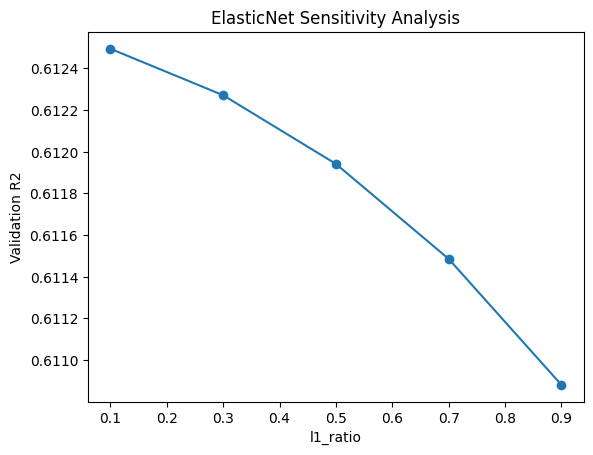

In [12]:
# =====================================================
# STEP 11 : ELASTICNET ANALYSIS
# =====================================================

elastic_coef = (best_model.named_steps["model"].coef_)
print(elastic_coef)
# ------------------------------
# Feature Selection
# ------------------------------

coef_df = pd.DataFrame({"Feature":X.columns,"ElasticNet":elastic_coef})
selected = coef_df[coef_df["ElasticNet"] != 0]
removed = coef_df[coef_df["ElasticNet"] == 0]

# ------------------------------
# Ridge vs Lasso vs ElasticNet
# ------------------------------

ridge_pipe = Pipeline([("scaler", StandardScaler()),("model", Ridge(alpha=1))])
lasso_pipe = Pipeline([("scaler", StandardScaler()),("model", Lasso(alpha=0.01,max_iter=10000))])

ridge_pipe.fit(X_train,y_train)
lasso_pipe.fit(X_train,y_train)

comparison = pd.DataFrame({
    "Feature":X.columns,
    "Ridge":ridge_pipe.named_steps["model"].coef_,
    "Lasso":lasso_pipe.named_steps["model"].coef_,
    "ElasticNet":elastic_coef})

print(comparison)

# ------------------------------
# l1_ratio Sensitivity
# ------------------------------

ratios = [0.1,0.3,0.5,0.7,0.9]
scores = []

for ratio in ratios:
    model = Pipeline([("scaler",StandardScaler()),("model",ElasticNet(alpha=0.01,l1_ratio=ratio,max_iter=10000,random_state=42))])

    model.fit(X_train, y_train)
    pred = model.predict(X_val)
    score = r2_score(y_val,pred)
    scores.append(score)

plt.plot(ratios,scores,marker="o")
plt.xlabel("l1_ratio")
plt.ylabel("Validation R2")
plt.title("ElasticNet Sensitivity Analysis")
plt.show()


In [13]:
# =====================================================
# STEP 12 : FINAL MODEL
# =====================================================

final_model = best_model

In [14]:
# =====================================================
# STEP 13 : TEST EVALUATION
# =====================================================
test_pred = final_model.predict(X_test)
test_mae = mean_absolute_error(y_test,test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test,test_pred))
test_r2 = r2_score(y_test,test_pred)
print("\nTEST RESULTS")
print("MAE :", test_mae)
print("RMSE:", test_rmse)
print("R2 :", test_r2)



TEST RESULTS
MAE : 0.5354100022186731
RMSE: 0.7327794356026827
R2 : 0.5902613534683565


In [ ]:
# =====================================================
# STEP 14 : INTERPRETATION
# =====================================================

print("\nFINAL COEFFICIENTS")
print(coef_df.sort_values(by="ElasticNet",ascending=False))
print("\nIntercept:",final_model.named_steps["model"].intercept_)


FINAL COEFFICIENTS
      Feature  ElasticNet
0      MedInc    0.832990
3   AveBedrms    0.319965
1    HouseAge    0.118001
4  Population   -0.003671
5    AveOccup   -0.045299
2    AveRooms   -0.284684
7   Longitude   -0.850658
6    Latitude   -0.880856

Intercept: 2.0629892621305457


In [16]:
# =====================================================
# STEP 15 : DEPLOYMENT READINESS
# =====================================================
print("\nDEPLOYMENT READINESS")
print("CV Mean:",cv_scores.mean())
print("Validation R2:",val_r2)
print("Test R2:",test_r2)



DEPLOYMENT READINESS
CV Mean: 0.2050442806134348
Validation R2: 0.6144113999293983
Test R2: 0.5902613534683565


# =====================================================
# INTERVIEW QUESTIONS
# =====================================================

"""
1. Why ElasticNet?
2. What is a
3. What is l1_ratio?
4. Difference between Ridge and Lasso?
5. Difference between Lasso and ElasticNet?
6. Difference between Ridge and ElasticNet?
7. What happens when l1_ratio=0?
   Pure Ridge
8. What happens when l1_ratio=1?
   Pure Lasso
9. Why scale data before ElasticNet?
10. Can ElasticNet perform feature selection?
11. Why does ElasticNet work better
    than Lasso for correlated features?
12. What is coefficient shrinkage?
13. What is regularization?
14. What is bias-variance tradeoff?
15. Explain ElasticNet mathematically.
"""